In this notebook, we are trying to split a polygon into n parts.

In [2]:
# load libraries
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shapely
from shapely.ops import split


# set crs, filepath, bbox
crs = "EPSG:3310"
county_filepath = "/capstone/wildfire_prep/data/ca_counties/CA_Counties.shp"
#sb_bbox = [-125, 34.25, -119.0, 38.0]

# load sb county polygon
counties = (
    gpd
    .read_file(county_filepath)
    .to_crs(crs)
    )

sb_county = (
    counties
    .loc[counties["NAME"] == "Santa Barbara"]
    .explode(ignore_index=True)
    .iloc[[0]]
    )

<Axes: >

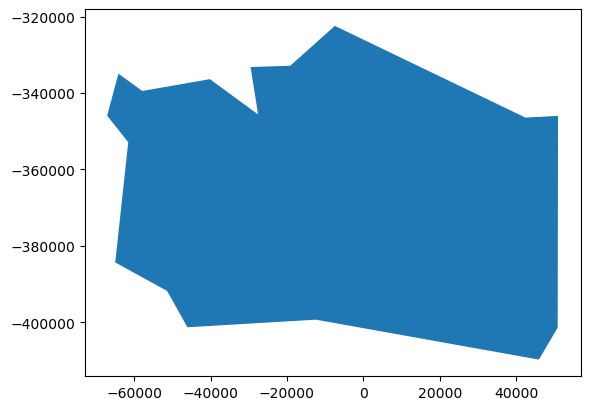

In [3]:
# simplify sb boundary geom
sb_simple = (
    sb_county
    .simplify(3500)
    .to_frame(name="geometry")
    .pipe(gpd.GeoDataFrame)
    )

sb_simple.plot()

In [4]:
# init number of polygons
num_poly = 4

Get triangle points from the center

In [5]:
# generate circle based on boundary
circle = (
    shapely
    .minimum_bounding_circle(sb_simple)
    .buffer(abs(sb_simple.iloc[[0]].total_bounds[0]) + 
            abs(sb_simple.iloc[[0]].total_bounds[2]))
    )

# get centroid of circle
centerpoint = circle.centroid




# add/reduce vertices to make the triangle segments (hopefully about) but less than this length
bnd = circle.boundary.segmentize(500)

# Extract the coordinates of all vertices of the segmentized boundary line
boundary_coords = list(bnd[0].coords)


Turn triangle coordinates into polygons

In [6]:
# get area of sb poly
original_area = sb_simple.area
# get area of each resulting polygon of the split
split_areas = original_area/num_poly


polygon_slices = [] # Store the intersection result in a list

# generate triangles
# for vertex and vertex next to it
for c1, c2 in zip(boundary_coords, boundary_coords[1:]):

    # init collection of points for each triangle
    circle_segment = shapely.MultiPoint([c1, c2, centerpoint[0]])

    # convex hull takes a collection of points and draws geometry by connecting the outside most points
    # in this case, it's connecting the points of the triangle together
    hull = circle_segment.convex_hull

    # clip the triangle to just the portion within sb county
    polygon_slices.append( hull.intersection(sb_simple) )

Plot simplified sb boundary with triangles

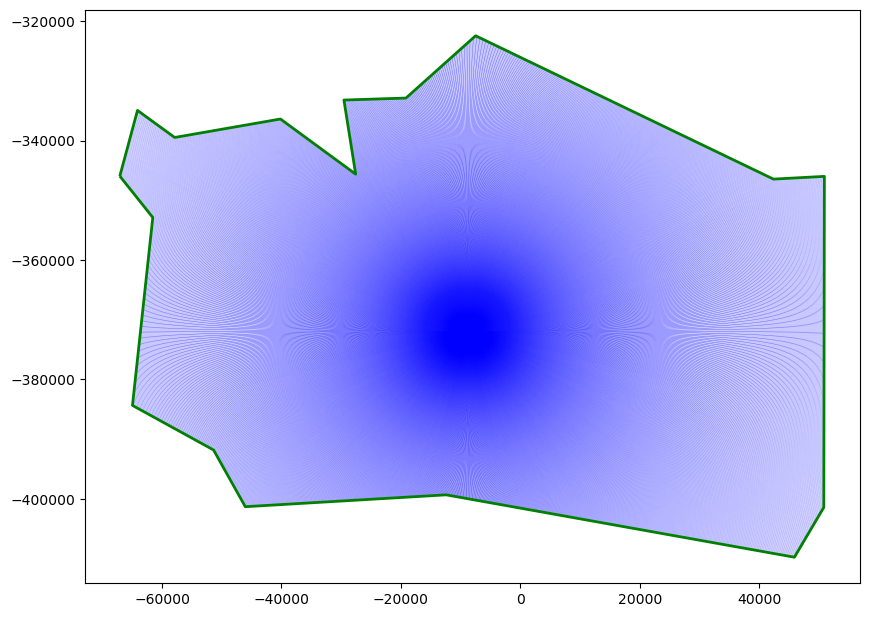

In [9]:
# I plotted using a segmentize distance of 20, to make the plot readable
ax = gpd.GeoSeries(sb_simple.geometry[0]).boundary.plot(figsize=(10,10), linewidth=2, color="green", zorder=2)    

for i in range(len(polygon_slices)):
    gpd.GeoSeries(polygon_slices[i].geometry[0]).boundary.plot(ax=ax, linewidth=0.08, color="blue", zorder=1)

# gpd.GeoSeries(polygon_slices[0].geometry[0]).boundary.plot(ax=ax, linewidth=0.5, color="blue", zorder=1)

# for i in range(len(polygon_slices[0:100])):
#     gpd.GeoSeries(polygon_slices[i].geometry[0]).boundary.plot(ax=ax, linewidth=0.5, color="blue", zorder=1)

In [ ]:
# Calculate the area of each triangle - the parts cut off with intersection
polygon_slice_areas = [p.area for p in polygon_slices] 

# Calculate a walking cumulative area over every triangle
slice_areas_cum = [float(x) for x in np.cumsum(polygon_slice_areas)]

# Calculate the optimal cumulative area
optimal_cumulative_areas = [float(x) for x in np.cumsum([split_areas]*(num_poly-1))] 

Find the optimal indices to divide the polygon slices

In [ ]:
# init result
best_indices_to_split = [0]

# for each area of the split polygons
for optimal_area in optimal_cumulative_areas:

    # subtract the cumulative area of the triangles from each polygon
    diffs = [abs(optimal_area-x) for x in slice_areas_cum]

    # find index of lowest discrepency between total split area
    best_split_index = diffs.index(min(diffs))

    # append it to the above list
    best_indices_to_split.append(best_split_index)

# append the length of polygon vertices list for some reason
best_indices_to_split.append(len(boundary_coords))

Create split polygons

In [50]:
# init polygon slice list
geometry_parts = []

# union based on window of indices (ex: union triangles [0:500])
for i1, i2 in zip(best_indices_to_split, best_indices_to_split[1:]):

    # union trianges from index i1 to index i2
    geometry_parts.append(shapely.ops.unary_union(polygon_slices[i1:i2]))

# convert to geopandas obj
split_geom = gpd.GeoSeries(geometry_parts)

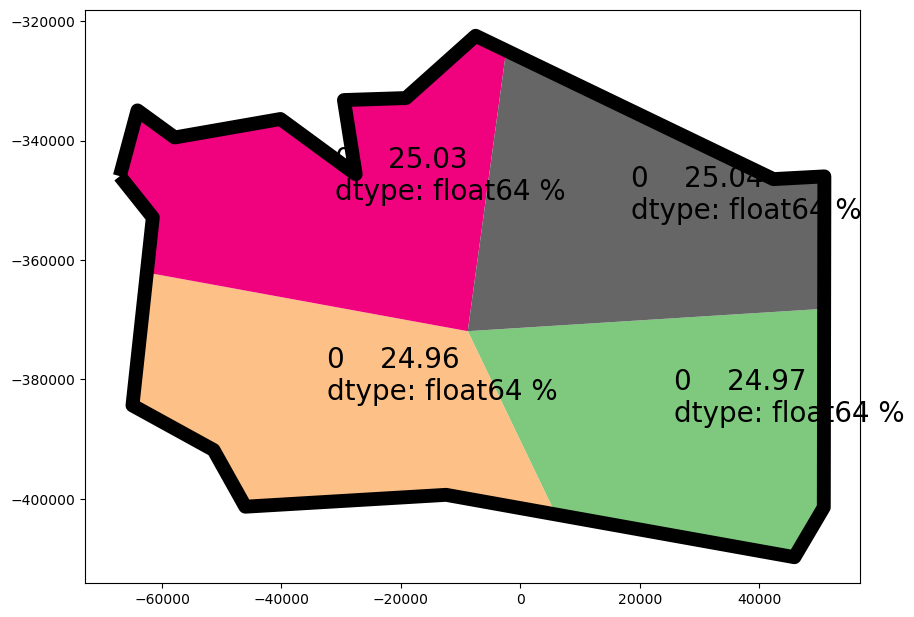

In [ ]:
#Plot the result
ax2 = (
    sb_simple
    .boundary
    .plot(
        figsize=(10, 10), 
        color="black", 
        zorder=2, 
        linewidth=10
        )
    )
split_geom.plot(ax=ax2, cmap="Accent", zorder=1)
for part in split_geom:
    part_area_prc = round(100*part.area/original_area, 2)
    x, y = part.centroid.xy
    x = x[0]
    y = y[0]
    #Annotate each slice with the relative area
    ax2.annotate(f"{part_area_prc} %", xy=(x, y), fontsize=10)

In [10]:
# lines = [
#     shapely.LineString([(x, sb_simple.bounds.values[0][1]), (x, sb_simple.bounds.values[0][3])])
#     for x in range(int(sb_simple.bounds.values[0][0]), int(sb_simple.bounds.values[0][2]), int((sb_simple.bounds.values[0][2] - sb_simple.bounds.values[0][0]) / 5))
# ]

# # # Split the polygon
# # for i in range(len(lines)):
# #     sb_simple = split(sb_simple, lines[i])

# # Convert the resulting parts into a GeoDataFrame
# # split_gdf = gpd.GeoDataFrame(geometry=list(boundary))

# test = split(sb_simple, lines[0])

In [11]:
# gpd.GeoDataFrame(geometry=lines).plot()

In [12]:
# line = shapely.LineString([(2, -1), (2, 5)])
# plt.plot(*line.xy)

# sb_simple.bounds.values[0][1]

# lines

# fig, ax = plt.subplots()

# sb_simple.plot(ax = ax)
# gpd.GeoDataFrame(geometry=lines).plot(ax = ax, color= "red")

In [13]:
# x_min, y_min, x_max, y_max = sb_simple.bounds.values[0]

# x_values = [x_min + i * (x_max - abs(x_min)) / 5 for i in range(1, 5)]

# splitting_lines = [shapely.LineString([(x, y_min), (x, y_max)]) for x in x_values]



In [14]:
# base_circle = shapely.minimum_bounding_circle(sb_simple)

# base_circle.total_bounds

Turning it into a generalized function

In [ ]:
def split_equal_area(num_splits, polygon):

        # get triangle points from center

    # generate circle based on boundary
    circle = (
    shapely
    .minimum_bounding_circle(polygon)
    .buffer(abs(polygon.iloc[[0]].total_bounds[0]) + 
            abs(polygon.iloc[[0]].total_bounds[2]))
    )

    # get centroid of circle
    centerpoint = circle.centroid

    # add/reduce vertices to make the triangle segments (hopefully about) but less than this length
    bnd = circle.boundary.segmentize(500)

    # Extract the coordinates of all vertices of the segmentized boundary line
    boundary_coords = list(bnd[0].coords)




        # turn triangle coordinates into polygons

    # get area of sb poly
    original_area = polygon.area
    # get area of each resulting polygon of the split
    split_areas = original_area/num_splits

    polygon_slices = [] #Store the intersection result in a list

    # generate triangles
    # for vertex and vertex next to it
    for c1, c2 in zip(boundary_coords, boundary_coords[1:]):

        # init collection of points for each triangle
        circle_segment = shapely.MultiPoint([c1, c2, centerpoint[0]])

        # convex hull takes a collection of points and draws geometry by connecting the outside most points
        # in this case, it's connecting the points of the triangle together
        hull = circle_segment.convex_hull

        # clip the triangle to just the portion within sb county
        polygon_slices.append( hull.intersection(polygon) )



        # find optimal way to split polygon for most equal area

    # Calculate the area of each triangle minus the parts cut off with intersection
    polygon_slice_areas = [p.area for p in polygon_slices]

    # Calculate a walking cumulative area over every triangle
    slice_areas_cum = [float(x) for x in np.cumsum(polygon_slice_areas)] 

    # Calculate the optimal cumulative area
    optimal_cumulative_areas = [float(x) for x in np.cumsum([split_areas]*(num_splits-1))] 




        # Find the optimal indices to divide the polygon slices

    # init result
    best_indices_to_split = [0]

    # for each area of the split polygons
    for optimal_area in optimal_cumulative_areas:

        # subtract the cumulative area of the triangles from each polygon
        diffs = [abs(optimal_area-x) for x in slice_areas_cum]

        # find index of lowest discrepency between total split area
        best_split_index = diffs.index(min(diffs))

        # append it to the above list
        best_indices_to_split.append(best_split_index)

    # append the length of polygon vertices list for some reason
    best_indices_to_split.append(len(boundary_coords))




        # Create split polygons

    # init polygon slice list
    geometry_parts = []

    # union based on window of indices (ex: union triangles [0:500])
    for i1, i2 in zip(best_indices_to_split, best_indices_to_split[1:]):

        # union trianges from index i1 to index i2
        geometry_parts.append(shapely.ops.unary_union(polygon_slices[i1:i2]))

    # convert to geopandas obj
    split_geom = gpd.GeoSeries(geometry_parts)



    # Plot the result
    ax2 = (
        polygon
        .boundary
        .plot(
            figsize=(10, 10), 
            color="black", 
            zorder=2, 
            linewidth=10
            )
        )
    split_geom.plot(ax=ax2, cmap="Accent", zorder=1)
    for part in split_geom:
        part_area_prc = round(100*part.area/original_area, 2)
        x, y = part.centroid.xy
        x = x[0]
        y = y[0]
        #Annotate each slice with the relative area
        ax2.annotate(f"{part_area_prc} %", xy=(x, y), fontsize=15)



    return split_geom

### Splitting

Split 1

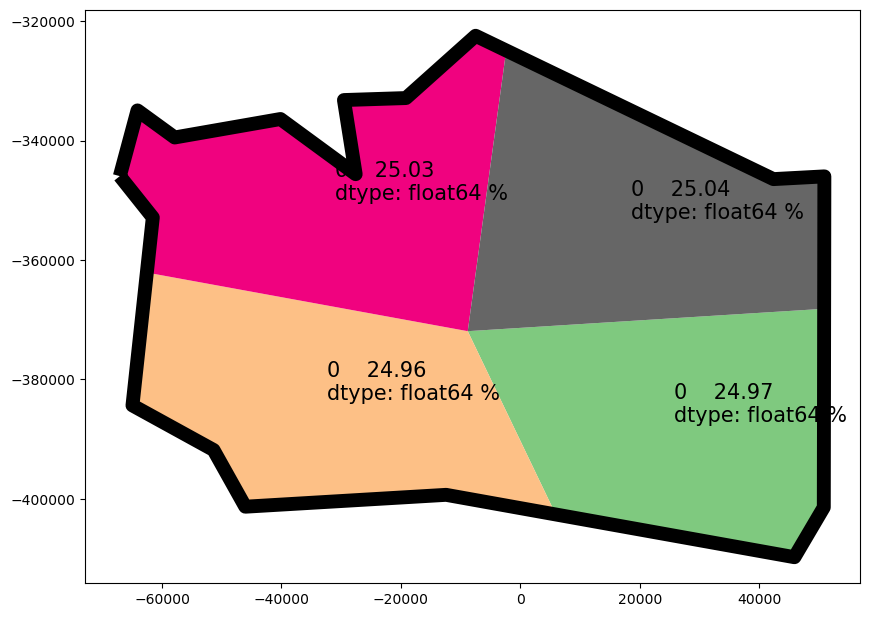

In [8]:
first_split = split_equal_area(4, sb_simple)

Reformatting for second split

In [152]:
first_split_format = gpd.GeoDataFrame(first_split).set_geometry(0).rename_geometry("geometry")
first_split_format.iloc[[1]].reset_index(drop = True)

,geometry
0,"POLYGON ((-64940.219 -384316.163, -64923.167 -..."


Splitting all subpolygons a second time

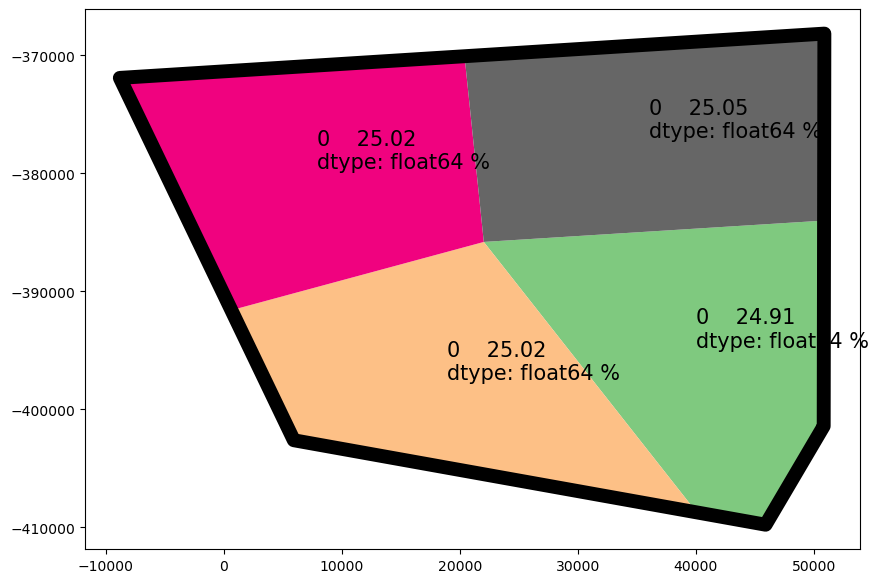

In [153]:
second_split_0 = split_equal_area(4, first_split_format.iloc[[0]].reset_index(drop = True))

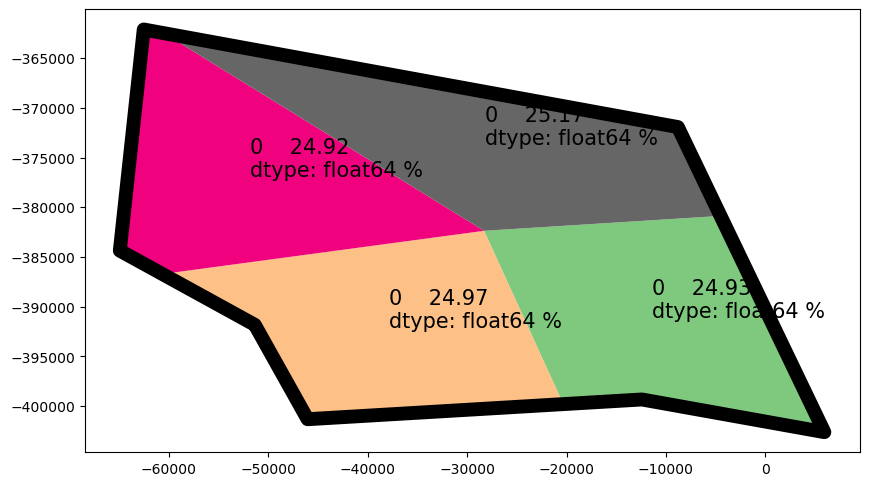

In [91]:
second_split_1 = split_equal_area(4, first_split_format.iloc[[1]].reset_index(drop = True))

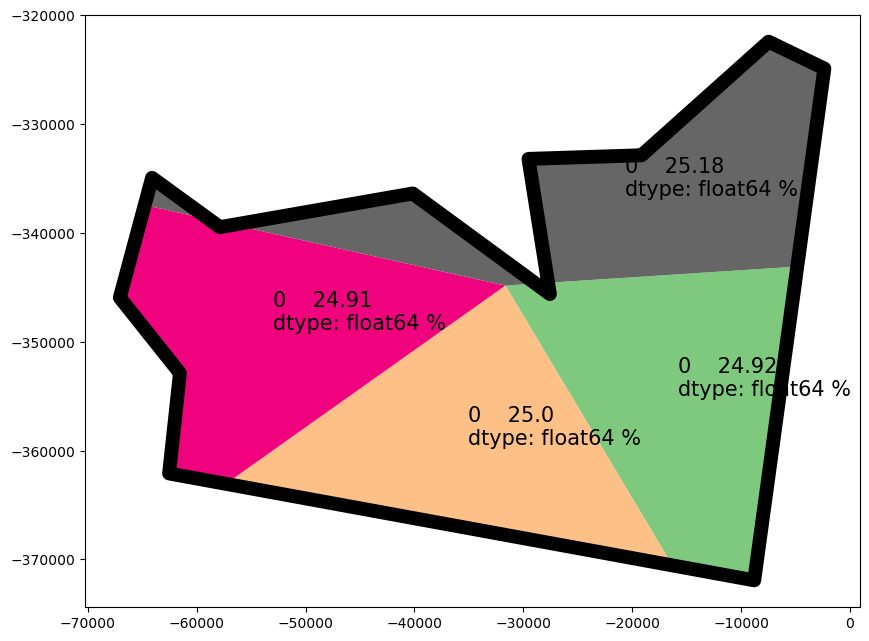

In [109]:
second_split_2 = split_equal_area(4, first_split_format.iloc[[2]].reset_index(drop = True))

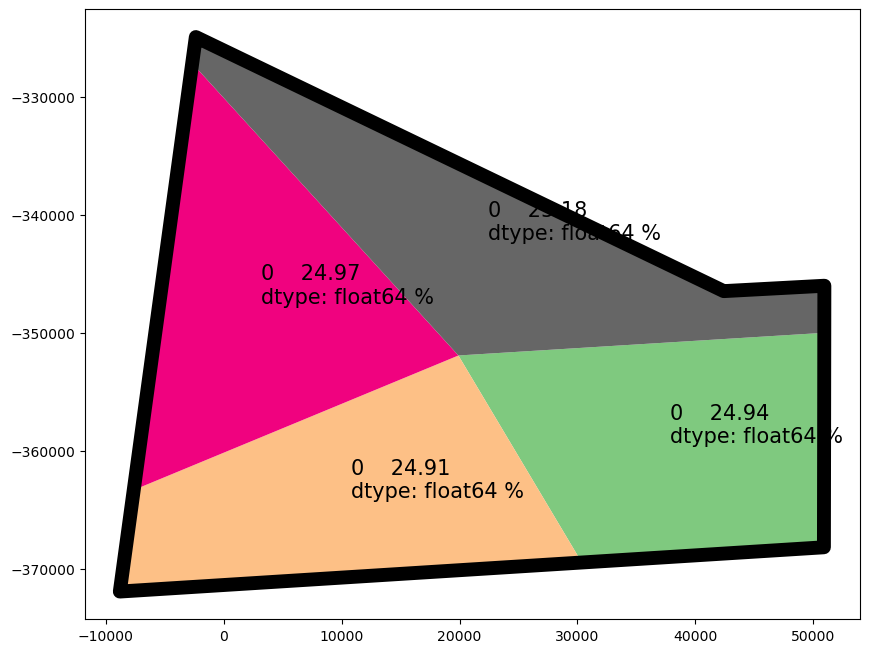

In [110]:
second_split_3 = split_equal_area(4, first_split_format.iloc[[3]].reset_index(drop = True))

In [111]:
all_splits = (
    pd.concat(
        [
            second_split_0, 
            second_split_1, 
            second_split_2, 
            second_split_3
        ]
        )
    .reset_index(drop = True)
    )

In [112]:
all_splits

0     POLYGON ((45181.344 -409645.159, 45120.024 -40...
1     POLYGON ((3002.711 -396496.027, 2954.715 -3963...
2     POLYGON ((-5393.893 -379008.253, -5477.226 -37...
3     POLYGON ((21048.958 -370046.234, 21131.381 -37...
4     POLYGON ((-19821.808 -399768.384, -19864.779 -...
5     POLYGON ((-51388.438 -391805.695, -51501.342 -...
6     POLYGON ((-64794.366 -384437.684, -64944.442 -...
7     POLYGON ((-60049.659 -362560.572, -59605.316 -...
8     POLYGON ((-27718.229 -345515.262, -27684.556 -...
9     POLYGON ((-49397.008 -364506.397, -49539.744 -...
10    POLYGON ((-66361.469 -346834.783, -66401.254 -...
11    MULTIPOLYGON (((-55536.255 -339075.463, -55471...
12    POLYGON ((30484.723 -369452.996, 30366.051 -36...
13    POLYGON ((-7401.103 -371834.925, -7727.752 -37...
14    POLYGON ((-7473.639 -362272.239, -7450.354 -36...
15    POLYGON ((5934.201 -328905.308, 6042.168 -3289...
dtype: geometry

<Axes: >

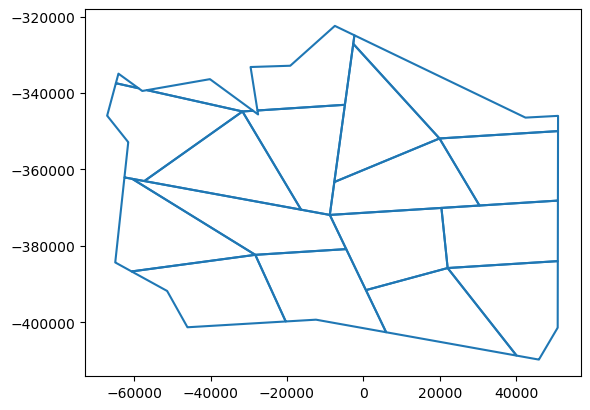

In [113]:
all_splits.boundary.plot()

#### experimental zone

In [ ]:
# def split_equal_area(num_splits, polygon, depth = 1):
#     circle = (
#     shapely
#     .minimum_bounding_circle(polygon)
#     .buffer(abs(polygon.iloc[[0]].total_bounds[0]) + 
#             abs(polygon.iloc[[0]].total_bounds[2]))
#     )

#     centerpoint = circle.centroid

#     # segmentation
#     bnd = circle.boundary.segmentize(500)

#     #Extract the coordinates of all vertices of the segmentized boundary line
#     boundary_coords = list(bnd[0].coords)



#     # make triangular polygons from center

#     original_area = polygon.area
#     split_areas = original_area/num_splits

#     polygon_slices = [] #Store the intersection result in a list
#     for c1, c2 in zip(boundary_coords, boundary_coords[1:]):
#         circle_segment = shapely.MultiPoint([c1, c2, centerpoint[0]])
#         hull = circle_segment.convex_hull
#         polygon_slices.append( hull.intersection(polygon) )



#     # Calculate the area of each intersection
#     polygon_slice_areas = [p.area for p in polygon_slices]

#     # Calculate the cumulative area
#     slice_areas_cum = [float(x) for x in np.cumsum(polygon_slice_areas)] 

#     # Calculate the optimal cumulative area
#     optimal_cumulative_areas = [float(x) for x in np.cumsum([split_areas]*(num_splits-1))] 



#     #Find the optimal indices to divide the polygon slices
#     best_indices_to_split = [0]
#     for optimal_area in optimal_cumulative_areas:
#         diffs = [abs(optimal_area-x) for x in slice_areas_cum]
#         best_split_index = diffs.index(min(diffs))
#         best_indices_to_split.append(best_split_index)
#     best_indices_to_split.append(len(boundary_coords))



#     # Union the polygon_slices[0:2011] into one part, polygon_slices[2011:3949] into one, ...
#     geometry_parts = []
#     resplit = []
#     i = 0
#     while i < depth:
#         for i1, i2 in zip(best_indices_to_split, best_indices_to_split[1:]):
#             geometry_parts.append(shapely.ops.unary_union(polygon_slices[i1:i2]))
#         gpd_parts = gpd.GeoSeries(geometry_parts)
#         if depth < 2: 
#             split_geom = gpd_parts
#         elif depth >= 2: 
#             for j in list(range(len(gpd_parts))): 
#                 format = gpd.GeoDataFrame(gpd_parts).set_geometry(0).rename_geometry("geometry")
#                 curr_poly = format.iloc[[j]].reset_index(drop = True)
#                 # resplit.extend(curr_poly)
#                 print(curr_poly)
#             split_geom = gpd.GeoDataFrame(resplit)
#         i = i + 1



#     # Plot the result
#     # ax2 = (
#     #     polygon
#     #     .boundary
#     #     .plot(
#     #         figsize=(10, 10), 
#     #         color="black", 
#     #         zorder=2, 
#     #         linewidth=10
#     #         )
#     #     )
#     # split_geom.plot(ax=ax2, cmap="Accent", zorder=1)
#     # for part in split_geom:
#     #     part_area_prc = round(100*part.area/original_area, 2)
#     #     x, y = part.centroid.xy
#     #     x = x[0]
#     #     y = y[0]
#     #     #Annotate each slice with the relative area
#     #     ax2.annotate(f"{part_area_prc} %", xy=(x, y), fontsize=15)



#     return split_geom